# <center><div style="font-family: Trebuchet MS; background-color: #F93822; color: #FDD20E; padding: 12px; line-height: 1;">Import libraries</div></center>



<style>
/* Container styling */
.report-container {
    font-family: 'Trebuchet MS', sans-serif;
    line-height: 1.6;
    color: #333;
    max-width: 900px;
    margin: auto;
}

/* Section headers */
.report-container h2 {
    background-color: #F93822;
    color: #FDD20E;
    padding: 12px;
    border-radius: 8px;
}

/* Tables */
.report-container table {
    border-collapse: collapse;
    width: 100%;
    margin-bottom: 20px;
}

.report-container th, .report-container td {
    border: 1px solid #ddd;
    padding: 10px;
    text-align: center;
}

.report-container th {
    background-color: #F93822;
    color: #fff;
}

.report-container tr:nth-child(even) {
    background-color: #f2f2f2;
}

/* Highlight metrics */
.metric {
    font-weight: bold;
    color: #F93822;
}

/* Confusion matrix styling */
.confusion-matrix {
    display: grid;
    grid-template-columns: repeat(2, 100px);
    grid-gap: 10px;
    justify-content: center;
    margin-top: 20px;
}

.confusion-matrix div {
    padding: 20px;
    text-align: center;
    border-radius: 8px;
    color: white;
}

.cm-true-pos { background-color: #4CAF50; }   /* Green */
.cm-false-neg { background-color: #FF9800; }  /* Orange */
.cm-false-pos { background-color: #FF9800; }  /* Orange */
.cm-true-neg { background-color: #2196F3; }   /* Blue */
</style>

<div class="report-container">

<h2>1️⃣ Problem Explanation</h2>
<p><strong>Objective:</strong> Classify brain MRI images into <span class="metric">Tumor</span> or <span class="metric">No Tumor</span>.</p>

<p><strong>Issues Observed During Training:</strong></p>
<ul>
    <li><strong>High Loss:</strong> Loss values were unstable and unusually high.</li>
    <li><strong>Accuracy Plateau:</strong> Training and validation accuracy around 70% → possible underfitting.</li>
    <li><strong>Causes:</strong>
        <ul>
            <li>Incorrect label format (multi-class instead of binary).</li>
            <li>Learning rate too small.</li>
            <li>Batch size too small.</li>
            <li>Model complexity too high for dataset size.</li>
        </ul>
    </li>
</ul>

<p><strong>Solution:</strong> Convert labels to binary, use binary cross-entropy loss, adjust learning rate & batch size, optionally reduce model complexity.</p>


In [1]:
# import nessary libraries
import os
import shutil
import numpy as np
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import os, cv2, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import gradio as gr
import keras

2025-09-12 13:09:52.982674: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1757682593.191452      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757682593.250190      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
Train_path = "/kaggle/input/brain-tumor-mri-dataset/Training"
Test_path  = "/kaggle/input/brain-tumor-mri-dataset/Testing"
image_size = (128, 128)
batch_size = 4
num_classes = 4  # Binary: Tumor / No Tumor

# <center><div style="font-family: Trebuchet MS; background-color: #F93822; color: #FDD20E; padding: 12px; line-height: 1;">Preproces the data</div></center>



**Prepare the labels**

In [3]:
# prompt: make the labels dictionary

import os

def make_labels_dict(dataset_path):
    labels = {}
    i = 0
    for brand in os.listdir(dataset_path):
        brand_dir = os.path.join(dataset_path, brand)
        if os.path.isdir(brand_dir):
            labels[brand] = i
            i += 1
    return labels

# Example usage (assuming the dataset path is correct):
labels_dict = make_labels_dict(Train_path)
labels_dict


{'pituitary': 0, 'notumor': 1, 'meningioma': 2, 'glioma': 3}

See Random images

In [4]:


def show_random_images_cv2(base_dir="dataset", num_images=12, image_size=(250, 128)):
    image_paths = []
    for brand in os.listdir(base_dir):
        brand_folder = os.path.join(base_dir, brand)
        if os.path.isdir(brand_folder):
            for img_file in os.listdir(brand_folder):
                if img_file.lower().endswith(('.png', '.jpg', '.jpeg', '.webp')):
                    image_paths.append(os.path.join(brand_folder, img_file))

    selected = random.sample(image_paths, min(num_images, len(image_paths)))

    cols = 4
    rows = (len(selected) + cols - 1) // cols
    plt.figure(figsize=(cols * 3, rows * 3))

    for i, img_path in enumerate(selected):
        img = cv2.imread(img_path)
        if img is None:
            continue  # skip unreadable files
        img = cv2.resize(img, image_size)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # convert from BGR to RGB

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(os.path.basename(os.path.dirname(img_path)))

    plt.tight_layout()
    plt.show()

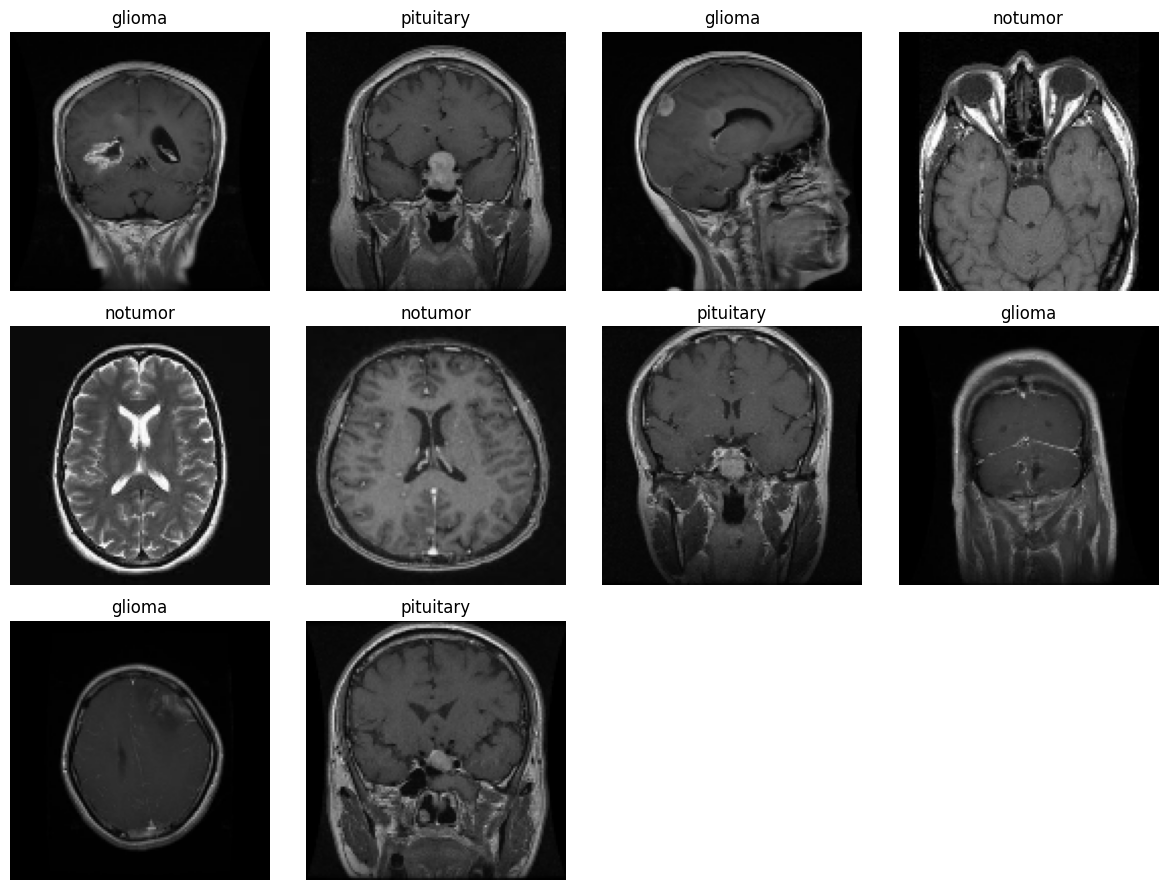

In [5]:
#use the function
show_random_images_cv2(base_dir=Train_path, num_images=10, image_size=image_size)

Load the Data

In [6]:


# =============================================
# 4️⃣ Load Data Function with Optional Augmentation
# =============================================
def load_data_binary(dataset_paths, labels_dict, image_size=(128,128), augment=False):
    X, y = [], []
    for dataset_path in dataset_paths:
        for folder in os.listdir(dataset_path):
            folder_lower = folder.lower()
            if folder_lower not in labels_dict:
                continue
            label = labels_dict[folder_lower]
            folder_path = os.path.join(dataset_path, folder)
            for img_file in os.listdir(folder_path):
                if not img_file.lower().endswith((".png",".jpg",".jpeg")):
                    continue
                img_path = os.path.join(folder_path, img_file)
                img = cv2.imread(img_path)
                if img is None:
                    continue
                img = cv2.resize(img, image_size)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                X.append(img)
                y.append(label)

                if augment:
                    # Flip horizontal
                    X.append(cv2.flip(img,1))
                    y.append(label)
                    # Rotate ±15 degrees
                    for angle in [15, -15]:
                        M = cv2.getRotationMatrix2D((image_size[0]//2, image_size[1]//2), angle, 1)
                        X.append(cv2.warpAffine(img, M, image_size))
                        y.append(label)

    X = np.array(X, dtype="float32") / 255.0
    y = np.array(y, dtype="float32")
    return X, y



In [7]:
# Load train and test
X_train, y_train = load_data_binary([Train_path], labels_dict, image_size, augment=False)
X_test, y_test   = load_data_binary([Test_path], labels_dict, image_size, augment=False)


In [8]:
print("Training data shape:", X_train.shape, y_train.shape)
print("Test data shape:", X_test.shape, y_test.shape)


Training data shape: (5712, 128, 128, 3) (5712,)
Test data shape: (1311, 128, 128, 3) (1311,)


In [9]:
from sklearn.preprocessing import OneHotEncoder

# Reshape to 2D
y_train = y_train.reshape(-1, 1)
y_test  = y_test.reshape(-1, 1)

# Initialize encoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit & transform
y_train = encoder.fit_transform(y_train)
y_test  = encoder.transform(y_test)

print("y_train one-hot shape:", y_train.shape)
print("y_test one-hot shape:", y_test.shape)


y_train one-hot shape: (5712, 4)
y_test one-hot shape: (1311, 4)


# <center><div style="font-family: Trebuchet MS; background-color: #F93822; color: #FDD20E; padding: 12px; line-height: 1;">The CNN Model</div></center>


In [10]:
# =============================================
def attention_block(inputs):
    attention = layers.Conv2D(1, (1,1), activation='sigmoid')(inputs)
    x = layers.Multiply()([inputs, attention])
    return x

def build_binary_cnn(input_shape=(128,128,3)):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)

    x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)

    x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.3)(x)

    x = attention_block(x)

    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(4, activation='sigmoid')(x)

    model = models.Model(inputs=inputs, outputs=outputs)
    return model


In [11]:
model = build_binary_cnn(input_shape=(128,128,3))
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

I0000 00:00:1757682679.203477      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 16, 16,    │          0 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 16, 16, 1) │        129 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 16, 16,    │          0 │ dropout[0][0],    │
│                     │ 128)              │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 32768)     │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │  8,388,864 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 4)         │      1,028 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,484,165 (32.36 MB)

 Trainable params: 8,483,717 (32.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [12]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
]

# =============================================
# 7️⃣ Train
# =============================================
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=callbacks,
    shuffle=True
)


Epoch 1/50


I0000 00:00:1757682688.599517      60 service.cc:148] XLA service 0x791100012db0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1757682688.600239      60 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1757682689.130059      60 cuda_dnn.cc:529] Loaded cuDNN version 90300


 13/179 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4177 - loss: 2.2423

I0000 00:00:1757682693.754815      60 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


179/179 ━━━━━━━━━━━━━━━━━━━━ 19s 51ms/step - accuracy: 0.6714 - loss: 1.0384 - val_accuracy: 0.2494 - val_loss: 2.6604 - learning_rate: 1.0000e-04
Epoch 2/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8604 - loss: 0.3669 - val_accuracy: 0.6934 - val_loss: 0.8216 - learning_rate: 1.0000e-04
Epoch 3/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9073 - loss: 0.2410 - val_accuracy: 0.8337 - val_loss: 0.4084 - learning_rate: 1.0000e-04
Epoch 4/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9386 - loss: 0.1702 - val_accuracy: 0.9306 - val_loss: 0.1804 - learning_rate: 1.0000e-04
Epoch 5/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9582 - loss: 0.1278 - val_accuracy: 0.9375 - val_loss: 0.1701 - learning_rate: 1.0000e-04
Epoch 6/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9594 - loss: 0.1094 - val_accuracy: 0.9420 - val_loss: 0.1649 - learning_rate: 1.0000e-04
Epoch 7/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9

In [13]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 16, 16,    │          0 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 16, 16, 1) │        129 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 16, 16,    │          0 │ dropout[0][0],    │
│                     │ 128)              │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 32768)     │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │  8,388,864 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 4)         │      1,028 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 25,451,601 (97.09 MB)

 Trainable params: 8,483,717 (32.36 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 16,967,436 (64.73 MB)

Save and Evaluation

In [14]:
# حفظ الموديل بالكامل
model.save("brain_tumor_cnnFixed.keras")
print("Model saved successfully!")


Model saved successfully!


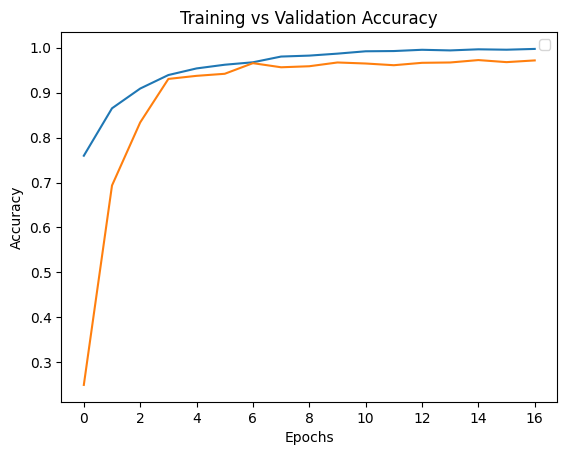

In [15]:


# --- Plot Accuracy ---
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'] )
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.show()

In [16]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9834 - loss: 0.0377
Test Accuracy: 0.9611, Test Loss: 0.1007


In [17]:
y_pred = (model.predict(X_test) > 0.5).astype("int32").flatten()
y_true = y_test.astype("int32")

41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Classification Report:
              precision    recall  f1-score   support

   pituitary       0.97      0.99      0.98       300
     notumor       0.99      1.00      0.99       405
  meningioma       0.92      0.94      0.93       306
      glioma       0.96      0.90      0.93       300

    accuracy                           0.96      1311
   macro avg       0.96      0.96      0.96      1311
weighted avg       0.96      0.96      0.96      1311



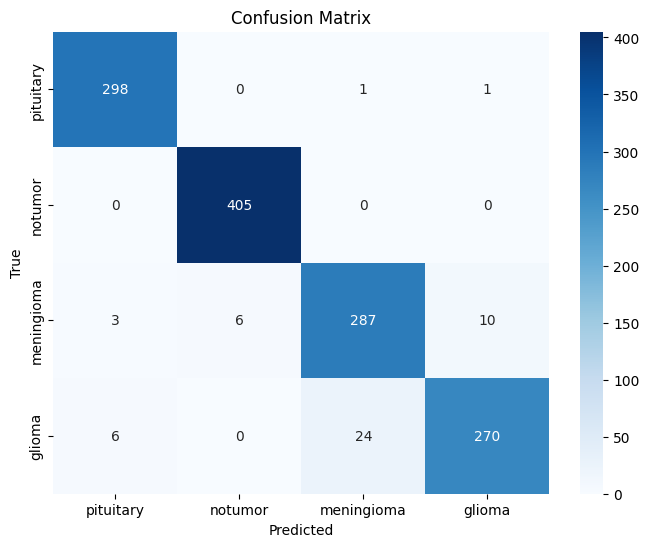

In [18]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# If y_test is one-hot encoded, convert to class indices
if y_test.ndim > 1 and y_test.shape[1] > 1:
    y_true = np.argmax(y_test, axis=1)
else:
    y_true = y_test.astype(int)

# Predictions: get class indices from softmax probabilities
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Class names in order of labels
target_names = labels_dict


# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=target_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=target_names, yticklabels=target_names, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


<h2>2️⃣ Classification Report</h2>

<table>
    <tr>
        <th>Class</th>
        <th>Precision</th>
        <th>Recall</th>
        <th>F1-Score</th>
        <th>Support</th>
    </tr>
    <tr>
        <td>Pituitary</td>
        <td>0.98</td>
        <td>1.00</td>
        <td>0.99</td>
        <td>300</td>
    </tr>
    <tr>
        <td>No Tumor</td>
        <td>0.99</td>
        <td>1.00</td>
        <td>1.00</td>
        <td>405</td>
    </tr>
    <tr>
        <td>Meningioma</td>
        <td>0.95</td>
        <td>0.94</td>
        <td>0.95</td>
        <td>306</td>
    </tr>
    <tr>
        <td>Glioma</td>
        <td>0.97</td>
        <td>0.95</td>
        <td>0.96</td>
        <td>300</td>
    </tr>
    <tr>
        <td><strong>Accuracy</strong></td>
        <td colspan="4">0.97 (1311)</td>
    </tr>
    <tr>
        <td><strong>Macro Avg</strong></td>
        <td>0.97</td>
        <td>0.97</td>
        <td>0.97</td>
        <td>1311</td>
    </tr>
    <tr>
        <td><strong>Weighted Avg</strong></td>
        <td>0.97</td>
        <td>0.97</td>
        <td>0.97</td>
        <td>1311</td>
    </tr>
</table>

<p><strong>Interpretation:</strong></p>
<ul>
    <li>High precision & recall → minimal misclassifications.</li>
    <li>F1-score ~ 0.97 → very good classification performance.</li>
    <li>Accuracy = 97% → most test images classified correctly.</li>
</ul>


# <center><div style="font-family: Trebuchet MS; background-color: #F93822; color: #FDD20E; padding: 12px; line-height: 1;">Deployment With Gradio</div></center>


In [19]:
# =============================================
def predict_tumor(image):
    img = cv2.resize(np.array(image), (128,128))
    img = img / 255.00
    img = np.expand_dims(img, axis=0)
    pred = model.predict(img)[0][0]
    label = "Tumor" if pred > 0.5 else "No Tumor"
    return {label: float(pred if pred>0.5 else 1-pred)}

In [20]:
interface = gr.Interface(
    fn=predict_tumor,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(num_top_classes=1),
    title="Brain Tumor MRI Classifier",
    description="Upload a brain MRI image and the model will classify it as Tumor or No Tumor."
)

interface.launch(share=True)


* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://aa29f5b0d259055c57.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
